# Human Resources Candidate Ranking
## Notebook 03 — Final Stage-1 Ranking and Stage-2 Relevance Feedback

This notebook fits the selected Stage-1 model and demonstrates recruiter-guided Stage-2 reranking. The ranking tables and plots used downstream are generated here first. Explanatory Markdown follows each code cell and states **what was done, how it was done, and why it matters**.

In [1]:
from pathlib import Path
import os, hashlib, math, re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "potential-talents-labelled.csv").exists() and (ROOT.parent / "potential-talents-labelled.csv").exists():
    ROOT = ROOT.parent
BUILD_DIR = Path(os.environ["PROJECT_BUILD_DIR"]) if os.environ.get("PROJECT_BUILD_DIR") else None
if BUILD_DIR:
    BUILD_DIR.mkdir(parents=True, exist_ok=True)

QUERIES = ("aspiring human resources", "seeking human resources")
RELEVANT_THRESHOLD = 2.0
_TOKEN_RE = re.compile(r"[a-z0-9]+")
_HR_TERMS = {"human", "resource", "resources", "hr", "hris"}
_INTENT_TERMS = {"aspiring", "seeking", "student", "internship", "entry", "entrylevel"}

def savefig(name):
    if BUILD_DIR:
        plt.savefig(BUILD_DIR / name, dpi=180, bbox_inches="tight")

def save_table(df, name):
    if BUILD_DIR:
        df.to_csv(BUILD_DIR / name, index=False)

def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower().replace("&", " and ")
    text = re.sub(r"\bhr\b", " human resources ", text)
    text = re.sub(r"\bentry[- ]level\b", " entrylevel ", text)
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def surface_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower().replace("&", " and ")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def tokenize(text):
    return _TOKEN_RE.findall(normalize_text(text))

def parse_connections(value):
    m = re.search(r"\d+", str(value).replace(",", ""))
    return float(m.group()) if m else np.nan

def stable_group_key(job_title, location, connection_num):
    payload = "|".join([
        normalize_text(job_title), normalize_text(location),
        "" if pd.isna(connection_num) else f"{float(connection_num):g}"
    ])
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()[:16]

def load_data():
    df = pd.read_csv(ROOT / "potential-talents-labelled.csv")
    df["connection_num"] = df["connection"].map(parse_connections)
    df["title_norm"] = df["job_title"].map(normalize_text)
    df["group_key"] = [stable_group_key(t,l,c) for t,l,c in zip(df.job_title,df.location,df.connection_num)]
    return df

def deduplicate(df):
    return (df.sort_values("id").groupby("group_key", sort=False)
        .agg(canonical_id=("id","min"), member_ids=("id", lambda s: tuple(int(x) for x in s)),
             duplicate_count=("id","size"), job_title=("job_title","first"),
             location=("location","first"), connection_num=("connection_num","first"),
             title_norm=("title_norm","first"), relevance=("final_revised_grade","first"))
        .reset_index().sort_values("canonical_id").reset_index(drop=True))

class BM25Index:
    def __init__(self, k1=1.5, b=0.75):
        self.k1=float(k1); self.b=float(b)
    def fit(self, documents):
        self.docs=[list(d) for d in documents]
        self.n_docs=len(self.docs)
        self.term_freqs=[Counter(d) for d in self.docs]
        self.doc_len=np.array([len(d) for d in self.docs], dtype=float)
        self.avgdl=float(self.doc_len.mean()) if self.n_docs else 0.0
        self.doc_freq=Counter()
        for d in self.docs: self.doc_freq.update(set(d))
        return self
    def _idf(self, term):
        df=self.doc_freq.get(term,0)
        return math.log(1.0 + (self.n_docs-df+0.5)/(df+0.5))
    def score(self, query_tokens):
        scores=np.zeros(self.n_docs, dtype=float)
        for term in query_tokens:
            idf=self._idf(term)
            for i,tf in enumerate(self.term_freqs):
                f=tf.get(term,0)
                if not f: continue
                norm=1-self.b+self.b*(self.doc_len[i]/max(self.avgdl,1e-12))
                scores[i]+=idf*(f*(self.k1+1))/(f+self.k1*norm)
        return scores

def minmax(x):
    x=np.asarray(x,dtype=float)
    lo,hi=np.nanmin(x),np.nanmax(x)
    return (x-lo)/(hi-lo) if hi>lo else np.zeros_like(x)

def build_features(groups, queries=QUERIES):
    docs=groups.title_norm.tolist(); toks=[tokenize(x) for x in docs]
    bm25=BM25Index().fit(toks)
    all_text=docs+[normalize_text(q) for q in queries]
    wv=TfidfVectorizer(preprocessor=normalize_text, tokenizer=str.split, token_pattern=None,
                       ngram_range=(1,2), sublinear_tf=True)
    cv=TfidfVectorizer(preprocessor=normalize_text, analyzer="char_wb", ngram_range=(3,5), sublinear_tf=True)
    wm=wv.fit_transform(all_text); cm=cv.fit_transform(all_text); n=len(docs)
    rows=[]
    for qi,q in enumerate(queries):
        qt=tokenize(q); qs=set(qt)
        bs=bm25.score(qt); ws=cosine_similarity(wm[:n],wm[n+qi]).ravel(); cs=cosine_similarity(cm[:n],cm[n+qi]).ravel()
        for i,g in groups.reset_index(drop=True).iterrows():
            ds=set(toks[i]); union=qs|ds
            qhr=qs & _HR_TERMS; qintent=qs & _INTENT_TERMS
            rows.append(dict(query_id=qi,query_text=q,group_key=g.group_key,canonical_id=int(g.canonical_id),
                job_title=g.job_title,location=g.location,duplicate_count=int(g.duplicate_count),relevance=float(g.relevance),
                bm25=float(bs[i]),tfidf_word=float(ws[i]),tfidf_char=float(cs[i]),
                jaccard=len(qs&ds)/len(union) if union else 0.0,
                containment=len(qs&ds)/len(qs) if qs else 0.0,
                hr_overlap=len(qhr&ds)/len(qhr) if qhr else 0.0,
                intent_overlap=len(qintent&ds)/len(qintent) if qintent else 0.0,
                log_connections=float(np.log1p(g.connection_num)) if pd.notna(g.connection_num) else 0.0))
    return pd.DataFrame(rows)

def dcg_at_k(y_true,y_score,k):
    y_true=np.asarray(y_true,float); y_score=np.asarray(y_score,float)
    order=np.argsort(-y_score,kind="mergesort")[:k]; rel=y_true[order]
    return float(np.sum((2**rel-1)/np.log2(np.arange(2,len(rel)+2)))) if len(rel) else 0.0

def ndcg_at_k(y_true,y_score,k):
    a=dcg_at_k(y_true,y_score,k); ideal=dcg_at_k(y_true,y_true,k)
    return a/ideal if ideal>0 else 0.0

def ap_at_k(y_true,y_score,k,threshold=RELEVANT_THRESHOLD):
    y_true=np.asarray(y_true,float); y_score=np.asarray(y_score,float); rel=y_true>=threshold
    total=int(rel.sum())
    if total==0: return 0.0
    hits=rel[np.argsort(-y_score,kind="mergesort")[:k]]
    ps=[hits[:i+1].mean() for i in range(len(hits)) if hits[i]]
    return float(sum(ps)/min(total,k))

def reciprocal_rank(y_true,y_score,threshold=RELEVANT_THRESHOLD):
    y_true=np.asarray(y_true,float); order=np.argsort(-np.asarray(y_score,float),kind="mergesort")
    hits=np.flatnonzero(y_true[order]>=threshold)
    return 1.0/(hits[0]+1) if len(hits) else 0.0

def ranking_metrics(y_true,y_score):
    return {"ndcg@5":ndcg_at_k(y_true,y_score,5),"ndcg@10":ndcg_at_k(y_true,y_score,10),
            "map@5":ap_at_k(y_true,y_score,5),"map@10":ap_at_k(y_true,y_score,10),
            "mrr":reciprocal_rank(y_true,y_score)}

FEATURES=["bm25","tfidf_word","tfidf_char","jaccard","containment","hr_overlap","intent_overlap"]

def grouped_cv(features):
    rows=[]; splitter=GroupKFold(n_splits=5)
    for alpha in [0.01,0.1,1,10,100]:
        for include_conn in [False,True]:
            cols=FEATURES+(["log_connections"] if include_conn else [])
            X=features[cols].to_numpy(float); y=features.relevance.to_numpy(float); gr=features.group_key.to_numpy()
            for fold,(tr,va) in enumerate(splitter.split(X,y,gr),1):
                model=Pipeline([("scale",StandardScaler()),("ridge",Ridge(alpha=alpha))])
                model.fit(X[tr],y[tr]); v=features.iloc[va].copy(); v["pred"]=model.predict(X[va])
                ms=[ranking_metrics(q.relevance,q.pred) for _,q in v.groupby("query_id")]
                avg={k:float(np.mean([m[k] for m in ms])) for k in ms[0]}
                rows.append({"config":f"ridge_a{alpha:g}_{'with_connections' if include_conn else 'text_only'}",
                             "alpha":alpha,"include_connections":include_conn,"fold":fold,**avg})
    folds=pd.DataFrame(rows)
    summary=(folds.groupby(["config","alpha","include_connections"],as_index=False)
             .agg(mean_ndcg10=("ndcg@10","mean"),std_ndcg10=("ndcg@10","std"),
                  mean_map10=("map@10","mean"),mean_mrr=("mrr","mean"))
             .sort_values(["mean_ndcg10","mean_map10","mean_mrr"],ascending=False).reset_index(drop=True))
    summary.insert(0,"rank",np.arange(1,len(summary)+1))
    return summary,folds

def fit_stage1(features, alpha=10.0, include_connections=False):
    cols=FEATURES+(["log_connections"] if include_connections else [])
    model=Pipeline([("scale",StandardScaler()),("ridge",Ridge(alpha=alpha))])
    model.fit(features[cols].to_numpy(float),features.relevance.to_numpy(float))
    s=features.copy(); s["prediction"]=model.predict(s[cols].to_numpy(float)); s["prediction_norm"]=0.0
    for _,idx in s.groupby("query_id").groups.items(): s.loc[idx,"prediction_norm"]=minmax(s.loc[idx,"prediction"])
    rank=(s.groupby("group_key",as_index=False).agg(canonical_id=("canonical_id","first"),job_title=("job_title","first"),
          location=("location","first"),duplicate_count=("duplicate_count","first"),relevance=("relevance","first"),
          stage1_score=("prediction_norm","max")))
    rank["stage1_rank"]=rank.stage1_score.rank(method="first",ascending=False).astype(int)
    return model,rank.sort_values(["stage1_rank","canonical_id"]).reset_index(drop=True)

def rocchio_scores(groups, starred_ids=(3,), rejected_ids=(), alpha=1.0,beta=0.75,gamma=0.15):
    id_to_group={int(r.canonical_id):r.group_key for _,r in groups.iterrows()}
    for _,r in groups.iterrows():
        for i in r.member_ids: id_to_group[int(i)]=r.group_key
    star={id_to_group[int(i)] for i in starred_ids}; reject={id_to_group[int(i)] for i in rejected_ids}
    docs=groups.title_norm.tolist(); q=[normalize_text(x) for x in QUERIES]
    v=TfidfVectorizer(preprocessor=normalize_text,tokenizer=str.split,token_pattern=None,ngram_range=(1,2),sublinear_tf=True)
    m=v.fit_transform(docs+q); dm=m[:len(docs)]; qm=m[len(docs):]
    g2r={g:i for i,g in enumerate(groups.group_key)}
    def centroid(gs):
        rows=[g2r[g] for g in gs]
        return np.asarray(dm[rows].mean(axis=0)) if rows else np.zeros((1,dm.shape[1]))
    pc,nc=centroid(star),centroid(reject); scores=[]
    for j in range(qm.shape[0]):
        pseudo=alpha*qm[j].toarray()+beta*pc-gamma*nc
        norm=np.linalg.norm(pseudo)
        if norm: pseudo/=norm
        scores.append(cosine_similarity(dm,pseudo).ravel())
    raw=np.max(np.vstack(scores),axis=0)
    out=groups[["group_key","canonical_id","job_title"]].copy(); out["feedback_score"]=minmax(raw)
    out["starred"]=out.group_key.isin(star); out["rejected"]=out.group_key.isin(reject)
    return out

def stage2(stage1, groups, starred_ids=(3,), rejected_ids=(), feedback_weight=0.35):
    fb=rocchio_scores(groups,starred_ids,rejected_ids)
    out=stage1.merge(fb[["group_key","feedback_score","starred","rejected"]],on="group_key",how="left")
    out["stage2_score"]=(1-feedback_weight)*out.stage1_score+feedback_weight*out.feedback_score
    out["stage2_rank"]=out.stage2_score.rank(method="first",ascending=False).astype(int)
    out["rank_change"]=out.stage1_rank-out.stage2_rank
    return out.sort_values(["stage2_rank","canonical_id"]).reset_index(drop=True)


### What was done, how, and why

**What was done.** The final-ranking environment and the same text, feature, metric, grouped-CV, and feedback utilities used in model selection were defined.

**How.** The notebook uses the flat labelled dataset, duplicate-safe groups, the selected Ridge setup, TF-IDF vector spaces for Rocchio feedback, and stable score blending.

**Why it matters.** Reusing the same modelling definitions prevents the final ranking from drifting away from the evaluated Stage-1 methodology.

,stage1_rank,canonical_id,job_title,relevance,stage1_score
0,1,99,Seeking Human Resources Position,2.0,1.000000
1,2,97,Aspiring Human Resources Professional,2.0,1.000000
2,3,3,Aspiring Human Resources Professional,3.0,1.000000
3,4,6,Aspiring Human Resources Specialist,3.0,0.995362
4,5,28,Seeking Human Resources Opportunities,3.0,0.956825
5,6,73,"Aspiring Human Resources Manager, seeking inte...",3.0,0.898895
6,7,79,Liberal Arts Major. Aspiring Human Resources A...,2.0,0.848970
7,8,10,Seeking Human Resources HRIS and Generalist Po...,3.0,0.847380
8,9,27,Aspiring Human Resources Management student se...,3.0,0.837437
9,10,72,Business Management Major and Aspiring Human R...,2.0,0.831805


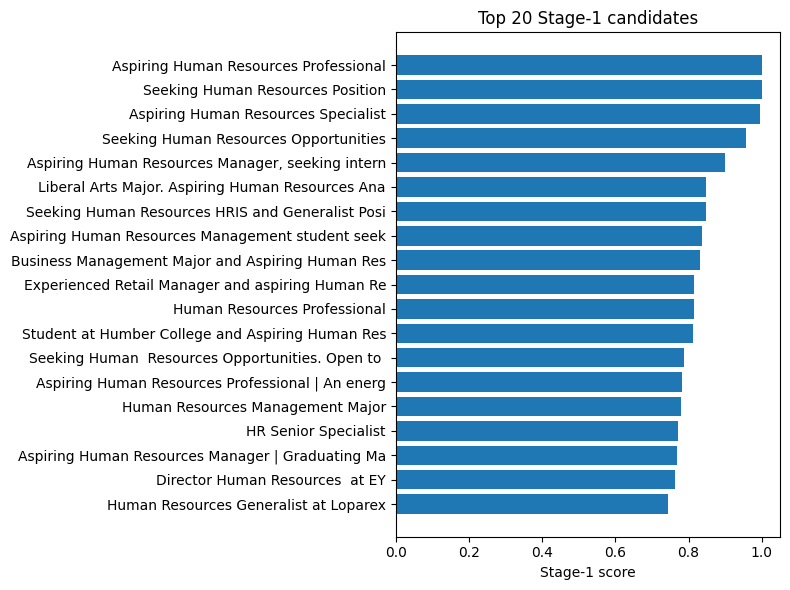

In [2]:
df=load_data(); groups=deduplicate(df); features=build_features(groups); summary,folds=grouped_cv(features)
_,stage1_rank=fit_stage1(features,alpha=10.0,include_connections=False)
display(stage1_rank[["stage1_rank","canonical_id","job_title","relevance","stage1_score"]].head(20))
save_table(stage1_rank,"table_16_stage1_group_ranking.csv")

top=stage1_rank.head(20).sort_values("stage1_score")
plt.figure(figsize=(8,6)); plt.barh(top.job_title.str.slice(0,48),top.stage1_score); plt.xlabel("Stage-1 score"); plt.title("Top 20 Stage-1 candidates"); plt.tight_layout(); savefig("09_stage1_top20.png"); plt.show()

### What was done, how, and why

**What was done.** The selected text-only Ridge model (`alpha=10`) was refit on all labelled profile groups and used to produce the final Stage-1 ranking and top-20 plot.

**How.** Query-level evidence is scored using the selected features, aggregated to group level, and sorted by Stage-1 score. Duplicate source rows remain linked through canonical profile groups.

**Why it matters.** This is the immutable baseline used for recruiter-facing search and for every Stage-2 feedback iteration. The table and figure are the authoritative Stage-1 ranking outputs for the reports.

,stage2_rank,canonical_id,job_title,stage1_rank,rank_change,stage1_score,feedback_score,stage2_score,starred
0,1,97,Aspiring Human Resources Professional,2,1,1.000000,1.000000,1.000000,False
1,2,3,Aspiring Human Resources Professional,3,1,1.000000,1.000000,1.000000,True
2,3,6,Aspiring Human Resources Specialist,4,1,0.995362,0.647272,0.873531,False
3,4,99,Seeking Human Resources Position,1,-3,1.000000,0.617156,0.866005,False
4,5,28,Seeking Human Resources Opportunities,5,0,0.956825,0.617156,0.837941,False
5,6,74,Human Resources Professional,12,6,0.813844,0.712458,0.778359,False
6,7,73,"Aspiring Human Resources Manager, seeking inte...",6,-1,0.898895,0.439735,0.738189,False
7,8,66,Experienced Retail Manager and aspiring Human ...,11,3,0.815739,0.471360,0.695206,False
8,9,10,Seeking Human Resources HRIS and Generalist Po...,8,-1,0.847380,0.358356,0.676221,False
9,10,79,Liberal Arts Major. Aspiring Human Resources A...,7,-3,0.848970,0.337343,0.669900,False


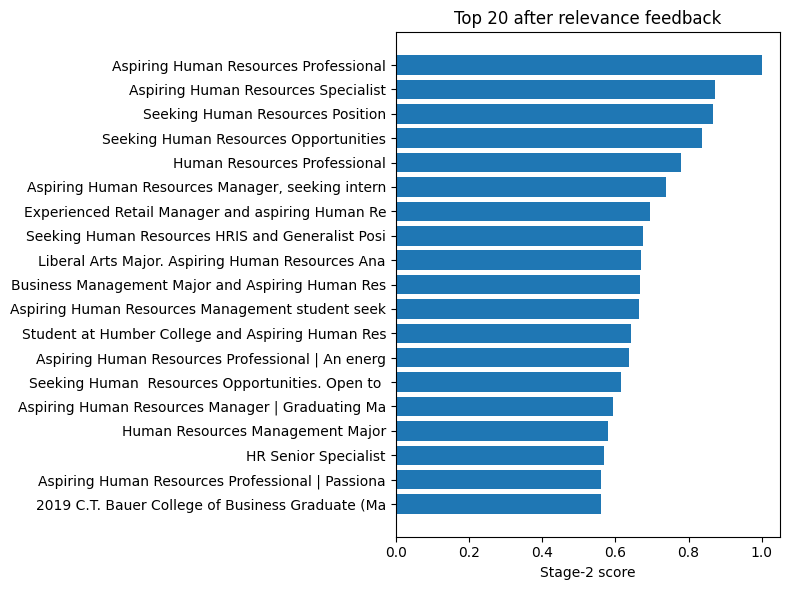

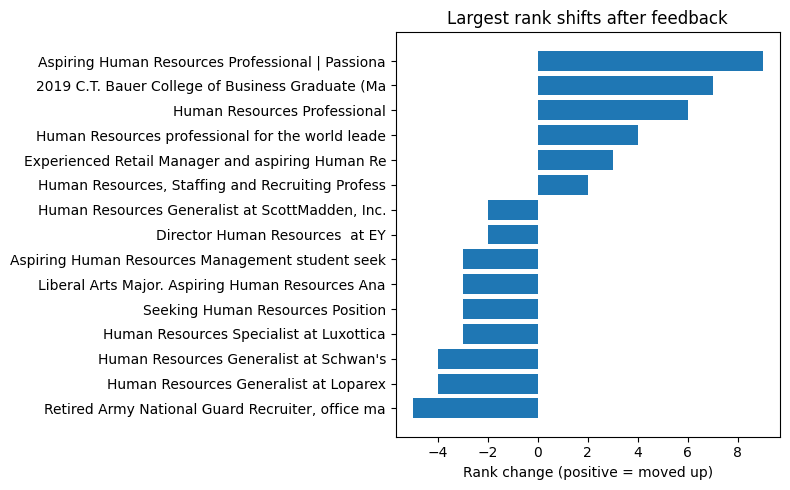

In [3]:
stage2_rank=stage2(stage1_rank,groups,starred_ids=(3,),rejected_ids=(),feedback_weight=.35)
display(stage2_rank[["stage2_rank","canonical_id","job_title","stage1_rank","rank_change","stage1_score","feedback_score","stage2_score","starred"]].head(20))
save_table(stage2_rank,"table_17_stage2_group_ranking.csv")

top=stage2_rank.head(20).sort_values("stage2_score")
plt.figure(figsize=(8,6)); plt.barh(top.job_title.str.slice(0,48),top.stage2_score); plt.xlabel("Stage-2 score"); plt.title("Top 20 after relevance feedback"); plt.tight_layout(); savefig("10_stage2_top20.png"); plt.show()
shift=stage2_rank.assign(abs_change=lambda x:x.rank_change.abs()).sort_values("abs_change",ascending=False).head(15).sort_values("rank_change")
plt.figure(figsize=(8,5)); plt.barh(shift.job_title.str.slice(0,48),shift.rank_change); plt.xlabel("Rank change (positive = moved up)"); plt.title("Largest rank shifts after feedback"); plt.tight_layout(); savefig("11_stage2_rank_shift.png"); plt.show()

### What was done, how, and why

**What was done.** Rocchio relevance feedback was applied to a demonstration star and blended with the immutable Stage-1 baseline. The notebook then produced the Stage-2 top ranking and rank-shift plots.

**How.** The adjusted query combines the original query with positive and negative feedback centroids using `alpha=1`, `beta=0.75`, and `gamma=0.15`. The feedback score contributes 35% and Stage-1 contributes 65%. Feedback on a raw ID is mapped to its unique profile group.

**Why it matters.** This allows recruiter preferences to alter ordering without recursively replacing the validated baseline. Similar profiles can move upward while the original Stage-1 evidence continues to anchor the result.

In [4]:
shift_table=(stage2_rank.assign(abs_change=lambda x:x.rank_change.abs()).sort_values("abs_change",ascending=False)[["canonical_id","job_title","stage1_rank","stage2_rank","rank_change"]].head(12)); display(shift_table); save_table(shift_table,"table_18_stage2_rank_shifts.csv")
print("Stage-1 top title:",stage1_rank.iloc[0].job_title)
print("Stage-2 top title:",stage2_rank.iloc[0].job_title)

,canonical_id,job_title,stage1_rank,stage2_rank,rank_change
18,76,Aspiring Human Resources Professional | Passio...,28,19,9
19,1,2019 C.T. Bauer College of Business Graduate (...,27,20,7
5,74,Human Resources Professional,12,6,6
25,70,"Retired Army National Guard Recruiter, office ...",21,26,-5
23,101,Human Resources Generalist at Loparex,20,24,-4
28,84,Human Resources professional for the world lea...,33,29,4
26,78,Human Resources Generalist at Schwan's,23,27,-4
7,66,Experienced Retail Manager and aspiring Human ...,11,8,3
24,68,Human Resources Specialist at Luxottica,22,25,-3
11,27,Aspiring Human Resources Management student se...,9,12,-3


Stage-1 top title: Seeking Human Resources Position
Stage-2 top title: Aspiring Human Resources Professional


### What was done, how, and why

**What was done.** The largest Stage-2 rank movements were tabulated and the top Stage-1 and Stage-2 titles were reported.

**How.** Absolute rank change is used to identify the candidates most affected by the demonstration feedback, while signed rank change shows whether each candidate moved up or down.

**Why it matters.** The table makes the effect of feedback auditable. Stage-2 should be interpreted as controlled search personalization, not as a new independent relevance model or a hiring decision.